# EP5 - Modelos de Sistemas discretos no Processamento de Sinais



Derek Ferreira Queiróz - 16862040 \
Ezekiel Gomes de Carvalho - 15510880 \
Leonardo Fraga Odloak - 14588277 \
Lucas Pires da Silva - 16885060\
Luis Felipe Quireza Menezes de Oliveira - 15472606\
Matheus de Oliveira Teodoro da Silva - 14598104\
Milena de Paula Silva - 16965010\
Sandro Kenvi Mayorga Cáceres - 11262880

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io
import random

In [ ]:
def convolve(x_n, h_n):
  y = []

  for j in range(len(x_n) - len(h_n)):
    valor = 0
    for i in range(len(h_n)):
      valor += x_n[j + i] * h_n[i]
    y.append(valor)
  return y

def testarFiltro1D_2(array, filtro):

    res = convolve(array,filtro)
    fig,ax1 = plt.subplots(figsize=(4,3))
    fig,ax2 = plt.subplots(figsize=(4,3))
    fig,ax3 = plt.subplots(figsize=(4,3))

    ax1.stem(res)
    ax1.set_title("Sinal Filtrado")

    ax2.stem(array)
    ax2.set_title("Sinal Original")

    ax3.stem(filtro)
    ax3.set_title("Filtro")
    plt.show()

In [ ]:
# Convolução 1D

def testarFiltro1D(array, filtro):

    res = np.convolve(array,filtro,mode='valid')
    fig,ax1 = plt.subplots(figsize=(8,5))
    fig,ax2 = plt.subplots(figsize=(8,5))
    fig,ax3 = plt.subplots(figsize=(8,5))

    ax1.stem(res)
    ax1.set_title("Sinal Filtrado")

    ax2.stem(array)
    ax2.set_title("Sinal Original")

    ax3.stem(filtro)
    ax3.set_title("Filtro")
    plt.show()

In [ ]:
#Convolução de sinal discreto
#Teste 1
h_n = np.array([-1,0,1]) # Filtro 1

# Array ordenado
x_n = np.array([1,2,3,4,5,6,7,8,9])
testarFiltro1D(x_n, h_n)
print()

# Array Aleatório
x_n = np.random.randint(0,100,size = 10)
testarFiltro1D(x_n, h_n)


In [ ]:
#Convolução de sinal discreto
#Teste ale
h_n = np.array([-1,0,1]) # Filtro ale

# Array ordenado
x_n = np.array([1,2,3,4,5,6,7,8,9])
testarFiltro1D_2(x_n, h_n)
print()

# Array Aleatório
x_n = np.random.randint(0,100,size = 10)
testarFiltro1D_2(x_n, h_n)

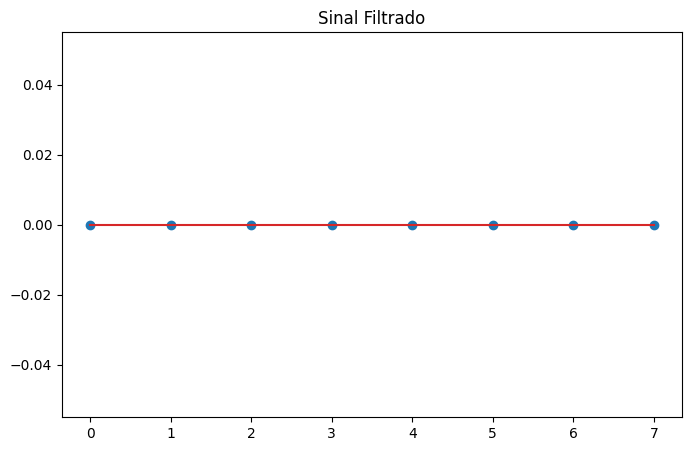

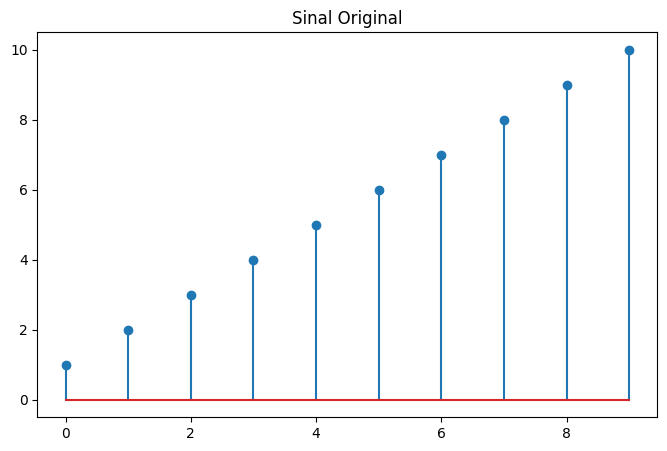

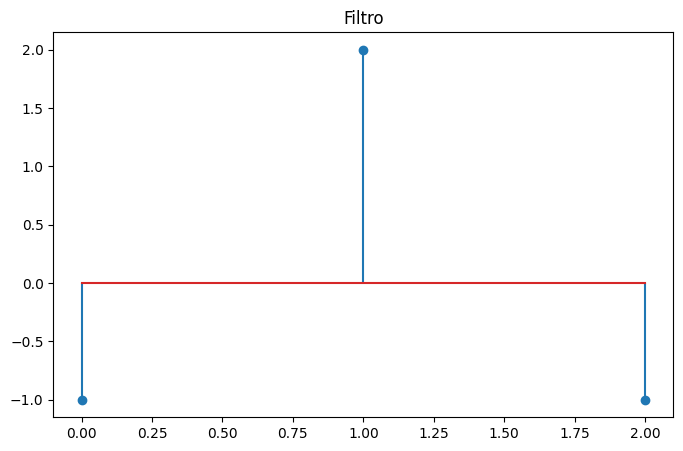

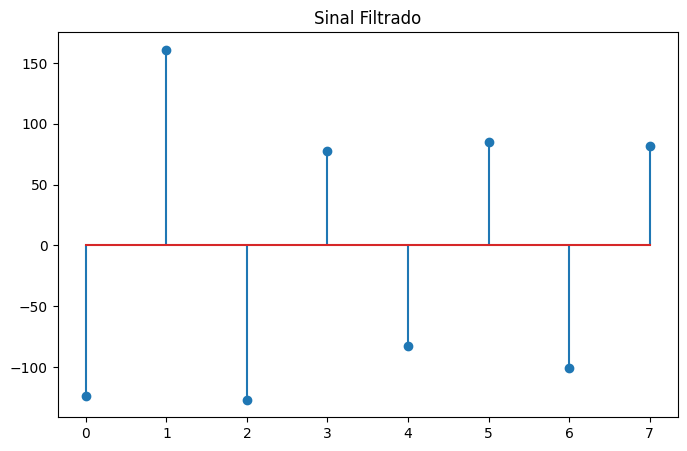

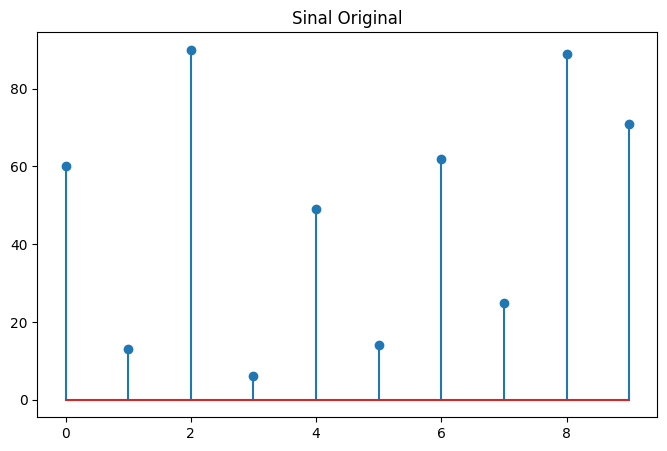

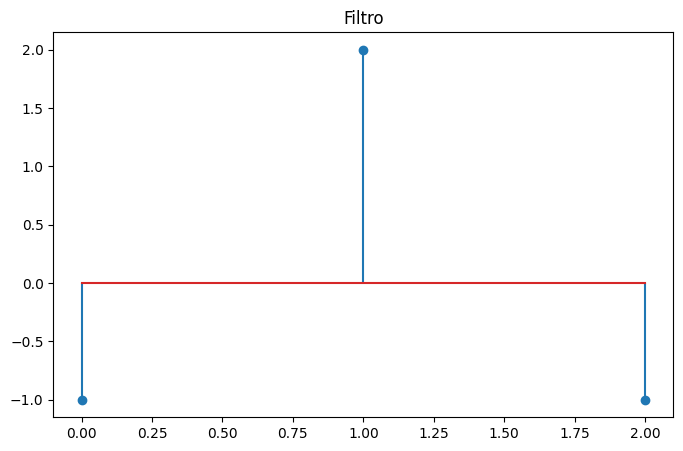

In [ ]:
#Convolução de sinal discreto
#Teste 2
h_n = np.array([-1,2,-1]) # Filtro 2

# Array ordenado
x_n = np.array([1,2,3,4,5,6,7,8,9,10])
testarFiltro1D(x_n, h_n)
print()

# Array Aleatório
x_n = np.random.randint(0,100,size = 10)
testarFiltro1D(x_n, h_n)

In [ ]:
#Convolução de sinal discreto
#Teste 3
h_n = np.array([0,-5,-1]) # Filtro 2

# Array ordenado
x_n = np.array([1,2,3,4,5,6,7,8,9,10])
testarFiltro1D(x_n, h_n)
print()

# Array Aleatório
x_n = np.random.randint(0,100,size = 10)
testarFiltro1D(x_n, h_n)

In [ ]:
def carregar_imagem():
    uploaded = files.upload()
    nome = list(uploaded.keys())[0]

    img = Image.open(io.BytesIO(uploaded[nome])).convert("L")
    img = np.array(img, dtype=float)

    return nome, img


def convolucao_linhas(img, filtro):
    h, w = img.shape
    out_w = w - len(filtro) + 1
    out = np.zeros((h, out_w))

    for i in range(h):
        out[i, :] = np.convolve(img[i, :], filtro, mode="valid")

    return out

def testar_filtro(filtro,nome,img,tamanho_filtro):
    horiz = convolucao_linhas(img, filtro)

    result_n = convolucao_linhas(horiz.T,filtro).T

    print("Imagem:", nome)
    print("Shape original:", img.shape)

    return result_n

def mostrar_imagem(nome, img, result_n):
    fig, axs = plt.subplots(1, 2, figsize=(10, 10))

    axs[0].imshow(img, cmap="gray")
    axs[0].set_title("Original")
    axs[0].axis("off")

    axs[1].imshow(result_n, cmap="gray")
    axs[1].set_title("Filtrada")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Filtro 1

tamanho_filtro = 15
# Quanto maior o tamanho do filtro, mais borrada fica a imagem.
nome, img = carregar_imagem()

# Sequencia de vários 1/(tamanho do filtro)

filtro1 = np.ones(tamanho_filtro) / tamanho_filtro
result_n = testar_filtro(filtro1,nome,img,tamanho_filtro)
print("Tamanho do filtro = ",15)
mostrar_imagem(nome, img, result_n)

tamanho_filtro = 60

filtro1 = np.ones(tamanho_filtro) / tamanho_filtro
result_n = testar_filtro(filtro1,nome,img,tamanho_filtro)
print("Tamanho do filtro = ",60)
mostrar_imagem(nome, img, result_n)


In [ ]:
#filtro 2
tamanho_filtro = 15
nome, img = carregar_imagem()

# Sequencia de números reais aleatórios entre -1 e 1
filtro2 = []
for i in range(tamanho_filtro):
  filtro2.append(random.randint(-1,1))

filtro2 = np.array(filtro2)
result_n = testar_filtro(filtro2,nome,img,tamanho_filtro)
print("Tamanho do filtro = ",15)
mostrar_imagem(nome, img, result_n)

tamanho_filtro = 60
filtro2 = []
for i in range(tamanho_filtro):
  filtro2.append(random.randint(-1,1))

filtro2 = np.array(filtro2)
result_n = testar_filtro(filtro2,nome,img,tamanho_filtro)
print("Tamanho do filtro = ",60)
mostrar_imagem(nome, img, result_n)

In [ ]:
#filtro 3:
tamanho_filtro = 15
nome, img = carregar_imagem()

# Sequencia de números aleatórios entre -1 e 1, porém uniformemente distribuídos
filtro3 = np.array(list(range(tamanho_filtro)))
filtro3 = np.sin(filtro3)
result_n = testar_filtro(filtro3,nome,img,tamanho_filtro)
print("Tamanho do filtro = ",15)
mostrar_imagem(nome, img, result_n)

tamanho_filtro = 30
filtro3 = np.array(list(range(tamanho_filtro)))
filtro3 = np.sin(filtro3)
result_n = testar_filtro(filtro3,nome,img,tamanho_filtro)
print("Tamanho do filtro = ",60)
mostrar_imagem(nome, img, result_n)

In [ ]:
# Filtro 4
tamanho_filtro = 15
nome, img = carregar_imagem()

filtro4 = np.array([-1,2,1,-1,2,1,-1,2,1,-1,2,1,-1,2,1])

result_n = testar_filtro(filtro4,nome,img,tamanho_filtro)
print("Tamanho do filtro = ",15)
mostrar_imagem(nome, img, result_n)

tamanho_filtro = 30
filtro4 = np.array([-1,2,1,-1,2,1,-1,2,1,-1,2,1,-1,2,1,-1,2,1,-1,2,1,-1,2,1,-1,2,1,-1,2,1])
result_n = testar_filtro(filtro4,nome,img,tamanho_filtro)
print("Tamanho do filtro = ",60)
mostrar_imagem(nome, img, result_n)